# Who Hunts Who?
## Comparing Three Knowledge Graph Construction Methods for Predator–Prey Relations

### Goal
Build a predator–prey knowledge graph from ~20 Wikipedia animal pages and compare three extraction approaches:

1. **Method A – Co-occurrence**
2. **Method B – Dependency Patterns**
3. **Method C – OpenIE-style Relation Extraction**

All methods are evaluated against the same gold standard using Precision, Recall and F1.


---
## Section 0 – Setup & Imports

In [13]:
# 0.1  Install dependencies (run once; comment out after first execution)
# After running this cell for the first time, restart the kernel and comment these lines out.
!pip install -q wikipedia-api spacy networkx pandas matplotlib seaborn
!python -m spacy download en_core_web_md -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [2]:
# 0.2  Imports

# --- standard library ---
import json
import time
import re
from pathlib import Path

# --- third-party ---
import wikipediaapi
import spacy
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Notebook display settings
pd.set_option("display.max_colwidth", 120)
%matplotlib inline
print("✅ All imports successful.")

✅ All imports successful.


---
## Section 1 – Dataset

A controlled corpus of ~20 Wikipedia animal pages forming a simple terrestrial food web. The corpus contains predators, intermediate species and common prey to allow multi-hop chains.


In [3]:
# 1.1  Animal lists and Wikipedia page title mapping

PREDATORS = ["Hawk", "Eagle", "Owl", "Fox", "Wolf", "Snake"]

MID_LEVEL = ["Frog", "Lizard", "Spider", "Bird", "Shrew", "Bat"]

PREY = ["Mouse", "Rabbit", "Squirrel", "Grasshopper", "Cricket", "Caterpillar", "Fly", "Beetle"]

ALL_ANIMALS = PREDATORS + MID_LEVEL + PREY

# Map animal label → exact Wikipedia page title.
# Most match directly; override here where the general page title differs.
WIKI_PAGE_MAP = {
    "Hawk":        "Hawk",
    "Eagle":       "Eagle",
    "Owl":         "Owl",
    "Fox":         "Fox",
    "Wolf":        "Wolf",
    "Snake":       "Snake",
    "Frog":        "Frog",
    "Lizard":      "Lizard",
    "Spider":      "Spider",
    "Bird":        "Bird",
    "Shrew":       "Shrew",
    "Bat":         "Bat",
    "Mouse":       "Mouse",
    "Rabbit":      "Rabbit",
    "Squirrel":    "Squirrel",
    "Grasshopper": "Grasshopper",
    "Cricket":     "Cricket (insect)",   # disambiguation: cricket sport vs insect
    "Caterpillar": "Caterpillar",
    "Fly":         "Fly",
    "Beetle":      "Beetle",
}

# Trophic colour map — used later for graph visualisations
TROPHIC_COLOR = {
    animal: color
    for animals, color in [
        (PREDATORS, "#e05c5c"),   # red   – top predators
        (MID_LEVEL, "#f0a500"),   # amber – mid-level
        (PREY,      "#4da06d"),   # green – lower trophic
    ]
    for animal in animals
}

print(f"Animal corpus: {len(ALL_ANIMALS)} animals total")
print(f"  Predators : {PREDATORS}")
print(f"  Mid-level : {MID_LEVEL}")
print(f"  Prey      : {PREY}")

Animal corpus: 20 animals total
  Predators : ['Hawk', 'Eagle', 'Owl', 'Fox', 'Wolf', 'Snake']
  Mid-level : ['Frog', 'Lizard', 'Spider', 'Bird', 'Shrew', 'Bat']
  Prey      : ['Mouse', 'Rabbit', 'Squirrel', 'Grasshopper', 'Cricket', 'Caterpillar', 'Fly', 'Beetle']


### 1.2 Fetching Wikipedia Pages

For each animal we retrieve:
- **Full plain text** of the page (for Methods A and B)
- **Internal wikilinks** (list of pages linked from this page, for Method C)

Pages are fetched once and cached locally (as a dict or JSON file) to avoid repeated API calls during development.

In [4]:
# 1.2  Fetch and cache Wikipedia pages
#
# Strategy:
#   - On first run, fetch all pages from the Wikipedia API and save to corpus_cache.json.
#   - On subsequent runs, load from cache to avoid repeated API calls.
#   - For each animal we store:
#       'text'  : full plain-text content of the page
#       'links' : list of Wikipedia page titles linked from this page (for Method C)
#       'url'   : canonical Wikipedia URL (for gold-standard citations)

CACHE_PATH = Path("corpus_cache.json")

def fetch_corpus(page_map: dict, force_refresh: bool = False) -> dict:
    """Fetch Wikipedia pages for all animals. Loads from cache if available."""

    if CACHE_PATH.exists() and not force_refresh:
        print(f"📂 Loading corpus from cache: {CACHE_PATH}")
        with open(CACHE_PATH, "r", encoding="utf-8") as f:
            return json.load(f)

    print("🌐 Fetching pages from Wikipedia API (this may take ~30 seconds)...")
    wiki = wikipediaapi.Wikipedia(
        language="en",
        user_agent="NLP-MAI-SS2026/1.0 (university project; contact: student@example.com)"
    )

    corpus = {}
    for animal, title in page_map.items():
        page = wiki.page(title)
        if not page.exists():
            print(f"  ⚠️  Page not found for '{animal}' (title: '{title}') — skipping.")
            continue

        corpus[animal] = {
            "title": page.title,
            "url":   page.fullurl,
            "text":  page.text,
            "links": list(page.links.keys()),   # titles of all linked Wikipedia pages
        }
        print(f"  ✅ {animal:15s}  ({len(page.text):,} chars, {len(page.links)} links)")

    # Persist to disk
    with open(CACHE_PATH, "w", encoding="utf-8") as f:
        json.dump(corpus, f, ensure_ascii=False, indent=2)
    print(f"\n💾 Corpus cached to {CACHE_PATH}")
    return corpus


# Run fetch (set force_refresh=True to re-download everything)
wiki_corpus = fetch_corpus(WIKI_PAGE_MAP, force_refresh=False)

📂 Loading corpus from cache: corpus_cache.json


### 1.3 Corpus Inspection

Quick sanity check: print page lengths and a sample sentence from each page to confirm the data looks as expected.

In [5]:
# 1.3  Corpus inspection — page lengths and a sample sentence per animal

rows = []
for animal, data in wiki_corpus.items():
    # Grab the first sentence that contains the animal name as a quick sanity snippet
    sentences = re.split(r'(?<=[.!?])\s+', data["text"])
    snippet = next(
        (s.strip() for s in sentences if animal.lower() in s.lower()),
        sentences[0].strip() if sentences else "(no text)"
    )
    rows.append({
        "animal":     animal,
        "trophic":    "predator" if animal in PREDATORS else ("mid" if animal in MID_LEVEL else "prey"),
        "chars":      len(data["text"]),
        "n_links":    len(data["links"]),
        "url":        data["url"],
        "snippet":    snippet[:200] + ("..." if len(snippet) > 200 else ""),
    })

corpus_df = pd.DataFrame(rows).sort_values(["trophic", "animal"]).reset_index(drop=True)
display(corpus_df[["animal", "trophic", "chars", "n_links", "snippet"]])

,animal,trophic,chars,n_links,snippet
0,Bat,mid,50398,451,"Bats (order Chiroptera ) are winged mammals, the only mammals capable of true and sustained flight."
1,Bird,mid,77772,1440,"Birds are a group of warm-blooded vertebrate animals constituting the class Aves, characterised by feathers, toothle..."
2,Frog,mid,79353,775,"A frog is any member of a diverse and largely semiaquatic group of short-bodied, tailless amphibian vertebrates comp..."
3,Lizard,mid,28181,364,Lizard is the common name used for all squamate reptiles other than snakes (and to a lesser extent amphisbaenians or...
4,Shrew,mid,7518,703,Shrews (family Soricidae) are small mole-like mammals classified in the order Eulipotyphla.
5,Spider,mid,55392,623,"Spiders (order Araneae) are air-breathing arthropods that have eight limbs, chelicerae with fangs generally able to ..."
6,Eagle,predator,21402,316,Eagle is the common name for certain large birds of prey within the family of the Accipitridae.
7,Fox,predator,16959,581,Foxes are small-to-medium-sized omnivorous mammals belonging to several genera of the family Canidae.
8,Hawk,predator,10341,127,Hawks are birds of prey of the family Accipitridae.
9,Owl,predator,31916,541,"Owls are birds from the order Strigiformes (), which includes over 200 species of mostly solitary and nocturnal bird..."


### 1.4 Debug: Corpus Health Check

Verifies that every animal in `ALL_ANIMALS` was fetched successfully, that no page is suspiciously short, and that the link lists are populated. This cell is safe to re-run at any time.

In [6]:
# 1.4  Debug — corpus health check

MIN_TEXT_CHARS  = 500    # pages shorter than this are likely disambiguation pages
MIN_LINK_COUNT  = 5     # pages with very few links are suspicious

issues   = []
ok_count = 0

print("=" * 60)
print(f"  Corpus health check  ({len(ALL_ANIMALS)} animals expected)")
print("=" * 60)

for animal in ALL_ANIMALS:
    if animal not in wiki_corpus:
        msg = f"❌ MISSING   {animal:15s}  — page was not fetched at all"
        print(msg); issues.append(msg)
        continue

    data   = wiki_corpus[animal]
    chars  = len(data["text"])
    nlinks = len(data["links"])
    animal_issues = []

    if chars < MIN_TEXT_CHARS:
        animal_issues.append(f"text too short ({chars} chars)")
    if nlinks < MIN_LINK_COUNT:
        animal_issues.append(f"very few links ({nlinks})")

    if animal_issues:
        msg = f"⚠️  WARNING  {animal:15s}  — {'; '.join(animal_issues)}"
        print(msg); issues.append(msg)
    else:
        print(f"✅ OK        {animal:15s}  {chars:>8,} chars   {nlinks:>4} links")
        ok_count += 1

print("=" * 60)
print(f"\nResult: {ok_count}/{len(ALL_ANIMALS)} pages passed all checks.")
if issues:
    print(f"\n{len(issues)} issue(s) found — review warnings above before proceeding.")
else:
    print("\n🎉 All pages look good! Ready to proceed to Section 2.")

  Corpus health check  (20 animals expected)
✅ OK        Hawk               10,341 chars    127 links
✅ OK        Eagle              21,402 chars    316 links
✅ OK        Owl                31,916 chars    541 links
✅ OK        Fox                16,959 chars    581 links
✅ OK        Wolf               56,540 chars   1150 links
✅ OK        Snake              60,712 chars    680 links
✅ OK        Frog               79,353 chars    775 links
✅ OK        Lizard             28,181 chars    364 links
✅ OK        Spider             55,392 chars    623 links
✅ OK        Bird               77,772 chars   1440 links
✅ OK        Shrew               7,518 chars    703 links
✅ OK        Bat                50,398 chars    451 links
✅ OK        Mouse               7,955 chars    130 links
✅ OK        Rabbit             40,958 chars    745 links
✅ OK        Squirrel           13,401 chars    652 links
✅ OK        Grasshopper        30,758 chars    385 links
✅ OK        Cricket            26,234 chars

---
## Section 2 – Gold Standard

Rather than collecting individual facts manually during evaluation, we define a small reference dataset in advance.

### Construction Rules
- Include only explicit predator→prey statements from Wikipedia.
- Each relation must be supported by at least one citation.
- Store evidence sentence, source URL and extracted edge.

### Example
| Predator | Prey | Evidence |
|-----------|------|----------|
| Fox | Rabbit | "Foxes feed on rabbits..." |
| Owl | Mouse | "Owls prey on mice..." |

This gold standard serves as the single reference set used to evaluate all three methods. Using a predefined benchmark improves reproducibility and ensures a fair comparison across approaches.


In [7]:

# Gold standard predator→prey relations (manually curated)
gold_standard = [
 {'predator':'Hawk','prey':'Mouse'},{'predator':'Hawk','prey':'Rabbit'},
 {'predator':'Eagle','prey':'Rabbit'},{'predator':'Eagle','prey':'Squirrel'},
 {'predator':'Owl','prey':'Mouse'},{'predator':'Fox','prey':'Rabbit'},
 {'predator':'Fox','prey':'Mouse'},{'predator':'Wolf','prey':'Rabbit'},
 {'predator':'Snake','prey':'Frog'},{'predator':'Snake','prey':'Mouse'},
 {'predator':'Frog','prey':'Cricket'},{'predator':'Frog','prey':'Fly'},
 {'predator':'Lizard','prey':'Grasshopper'},{'predator':'Spider','prey':'Fly'},
 {'predator':'Bat','prey':'Beetle'},{'predator':'Shrew','prey':'Beetle'}]
gold_df=pd.DataFrame(gold_standard)
gold_edges=set(zip(gold_df.predator,gold_df.prey))
gold_df.head()


,predator,prey
0,Hawk,Mouse
1,Hawk,Rabbit
2,Eagle,Rabbit
3,Eagle,Squirrel
4,Owl,Mouse


### 2.2 Gold Standard Summary

Display the full gold standard table and a small network visualisation of the true food web.

,predator,prey
0,Hawk,Mouse
1,Hawk,Rabbit
2,Eagle,Rabbit
3,Eagle,Squirrel
4,Owl,Mouse
5,Fox,Rabbit
6,Fox,Mouse
7,Wolf,Rabbit
8,Snake,Frog
9,Snake,Mouse


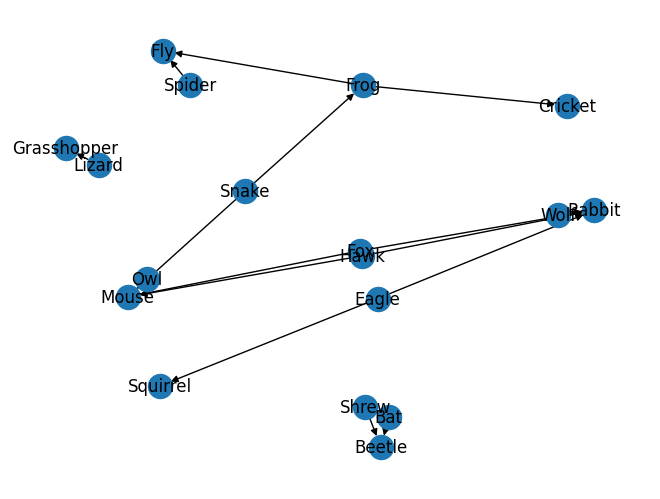

In [8]:
display(gold_df)
g=nx.DiGraph(); g.add_edges_from(gold_edges)
pos=nx.spring_layout(g,seed=42)
nx.draw(g,pos,with_labels=True)


---
## Section 3 – Method A: Co-occurrence

Create an edge A→B when both animals appear in the same sentence.

**Expected:** high recall, lower precision.


In [12]:
import re
import time
from itertools import product

def co_occurrence_graph():
    t0 = time.time()
    edges_A = set()

    for predator in PREDATORS + MID_LEVEL:
        txt = wiki_corpus.get(predator, {}).get('text', '')

        for sent in re.split(r'(?<=[.!?])\s+', txt):
            for prey in ALL_ANIMALS:
                if (
                    prey != predator
                    and predator.lower() in sent.lower()
                    and prey.lower() in sent.lower()
                ):
                    edges_A.add((predator, prey))

    time_A = time.time() - t0

    graph_A = nx.DiGraph()
    graph_A.add_edges_from(edges_A)

    return graph_A, edges_A, time_A

# Example usage
graph_A, edges_A, time_A = co_occurrence_graph()
len(edges_A)

75

### 3.2 Method A – Results

Inspect the extracted edges and visualise the resulting graph.

Edges 75
[('Bird', 'Bat'), ('Shrew', 'Bat'), ('Fox', 'Bat'), ('Lizard', 'Bird'), ('Snake', 'Lizard'), ('Frog', 'Fly'), ('Hawk', 'Eagle'), ('Snake', 'Mouse'), ('Bird', 'Fly'), ('Owl', 'Fly'), ('Bat', 'Owl'), ('Hawk', 'Owl'), ('Bat', 'Bird'), ('Hawk', 'Bird'), ('Bat', 'Fox'), ('Eagle', 'Snake'), ('Lizard', 'Frog'), ('Fox', 'Wolf'), ('Bat', 'Hawk'), ('Bat', 'Frog')]


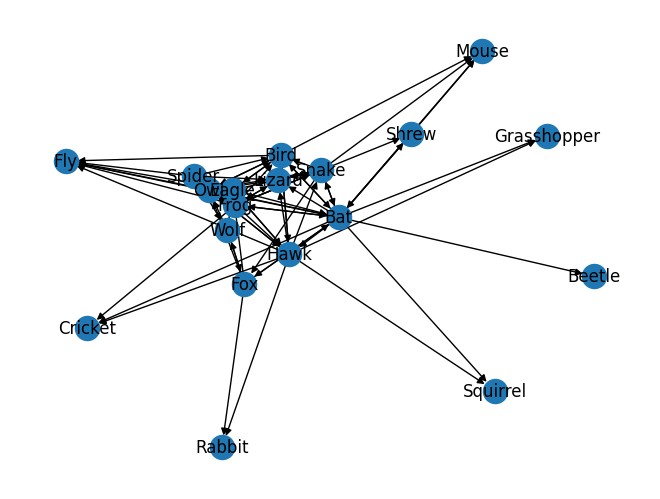

In [10]:
print('Edges',len(edges_A)); print(list(edges_A)[:20])
nx.draw(graph_A,nx.spring_layout(graph_A,seed=1),with_labels=True)


---
## Section 4 – Method B: Dependency Patterns

Use dependency parsing and hand-crafted patterns such as *eats*, *hunts*, *preys on* and *feeds on* to extract explicit predator→prey relations.

**Expected:** highest precision.


In [17]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.1/12.8 MB 2.2 MB/s eta 0:00:06
     - -------------------------------------- 0.5/12.8 MB 3.3 MB/s eta 0:00:04
     -- ------------------------------------- 0.6/12.8 MB 3.4 MB/s eta 0:00:04
     --- ------------------------------------ 1.0/12.8 MB 4.2 MB/s eta 0:00:03
     --- ------------------------------------ 1.1/12.8 MB 4.2 MB/s eta 0:00:03
     ---- ----------------------------------- 1.4/12.8 MB 4.5 MB/s eta 0:00:03
     ----- ---------------------------------- 1.6/12.8 MB 4.8 MB/s eta 0:00:03
     ----- ---------------------------------- 1.9/12.8 MB 4.6 MB/s eta 0:00:03
     ------ --------------------------------- 2.2/12.8 MB 5.0 MB/s eta 0:00:03
     ------- -------------------------------- 2.4/12.8 MB 4.8 MB/s eta 0:00:03
     -------- ------------------------------- 2.7/12.8 MB 5.0 MB/s eta 0:00:03
     --------- ------------------------------ 3.0/12.8 MB 5

In [29]:
import time
import spacy
import networkx as nx
from spacy.matcher import PhraseMatcher

nlp = spacy.load("en_core_web_sm")


def build_predation_graph_method_b(
    wiki_corpus,
    PREDATORS,
    MID_LEVEL,
    ALL_ANIMALS,
    max_text_len=200000,
):
    """
    Method B: Dependency parsing + entity linking (PhraseMatcher)
    """

    t0 = time.time()

    edges = set()
    evidence = []

    predators_set = {p.lower() for p in PREDATORS + MID_LEVEL}
    animals_set = {a.lower() for a in ALL_ANIMALS}

    # -----------------------------
    # 1. PhraseMatcher for animals
    # (fixes multi-word species like "snow leopard")
    # -----------------------------
    matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
    animal_patterns = [nlp.make_doc(a) for a in ALL_ANIMALS]
    matcher.add("ANIMALS", animal_patterns)

    for predator in PREDATORS + MID_LEVEL:
        text = wiki_corpus.get(predator, {}).get("text", "")[:max_text_len]
        doc = nlp(text)

        for sent in doc.sents:
            sent_doc = nlp(sent.text)
            sent_lower = sent.text.lower()

            # quick skip
            if not any(a in sent_lower for a in animals_set):
                continue

            # -----------------------------
            # 2. Entity detection via matcher
            # -----------------------------
            matches = matcher(sent_doc)
            spans = {}
            for _, start, end in matches:
                span = sent_doc[start:end]
                spans[span.text.lower()] = span.text

            # -----------------------------
            # 3. Dependency parsing (core Method B)
            # -----------------------------
            for token in sent_doc:
                if token.pos_ != "VERB":
                    continue

                lemma = token.lemma_.lower()

                subjects = [w for w in token.lefts if w.dep_ in ("nsubj", "nsubjpass")]
                objects = [w for w in token.rights if w.dep_ in ("dobj", "obj", "attr", "oprd")]

                subj_is_predator = any(
                    s.text.lower() == predator.lower()
                    for s in subjects
                )

                if subj_is_predator:
                    for obj in objects:
                        obj_key = obj.text.lower()
                        if obj_key in spans and obj_key in animals_set:
                            edges.add((predator, spans[obj_key]))
                            evidence.append((predator, spans[obj_key], sent.text))

                # -----------------------------
                # 4. Prepositional pattern
                # "X preys on Y"
                # -----------------------------
                if lemma in {"prey", "feed", "hunt", "eat", "attack", "kill", "consume", "devour"}:
                    for child in token.children:
                        if child.dep_ == "prep" and child.text.lower() == "on":
                            for obj in child.children:
                                obj_key = obj.text.lower()
                                if obj_key in spans and obj_key in animals_set:
                                    edges.add((predator, spans[obj_key]))
                                    evidence.append((predator, spans[obj_key], sent.text))

    runtime = time.time() - t0

    graph = nx.DiGraph()
    graph.add_edges_from(edges)

    return graph, edges, evidence, runtime

### 4.3 Method B – Results

Inspect extracted edges, highlight any interesting dependency parses, and visualise the graph.

In [30]:
graph_B, edges_B, evidence_B, time_B = build_predation_graph_method_b(
    wiki_corpus,
    PREDATORS,
    MID_LEVEL,
    ALL_ANIMALS,
    max_text_len=200000,
)

print("Edges:", len(edges_B))
print("Time (s):", time_B)
print("Evidence sample:", evidence_B[:5])

Edges: 1
Time (s): 51.97580122947693
Evidence sample: [('Eagle', 'eagle', "Genus Spizaetus\nBlack hawk-eagle, S. tyrannus\nOrnate hawk-eagle, S. ornatus\nBlack-and-white hawk-eagle, S. melanoleucus – formerly Spizastur\nBlack-and-chestnut eagle, S. isidori – formerly Oroaetus\nGenus Lophotriorchis\nRufous-bellied eagle, L. kienerii \nGenus Polemaetus\nMartial eagle, Polemaetus bellicosus\nGenus Lophaetus\nLong-crested eagle, Lophaetus occipitalis – possibly belongs in Ictinaetus\nGenus Ictinaetus\nBlack eagle, Ictinaetus malaiensis\nGenus Hieraaetus\nAyres's hawk-eagle, H. ayresii\nLittle eagle, H. morphnoides\nPygmy eagle, H. weiskei – previously subspecies H. m. weiskei\nBooted eagle, H. pennatus\nHaast's eagle, †H. moorei\nGenus Aquila\nBonelli's eagle, Aquila fasciata – formerly Hieraaetus fasciatus\nAfrican hawk-eagle, A. spilogaster – formerly in Hieraaetus\nCassin's hawk-eagle, A. africana – formerly in Hieraaetus or Spizaetus genera\nGolden eagle, A. chrysaetos\nEastern imperia

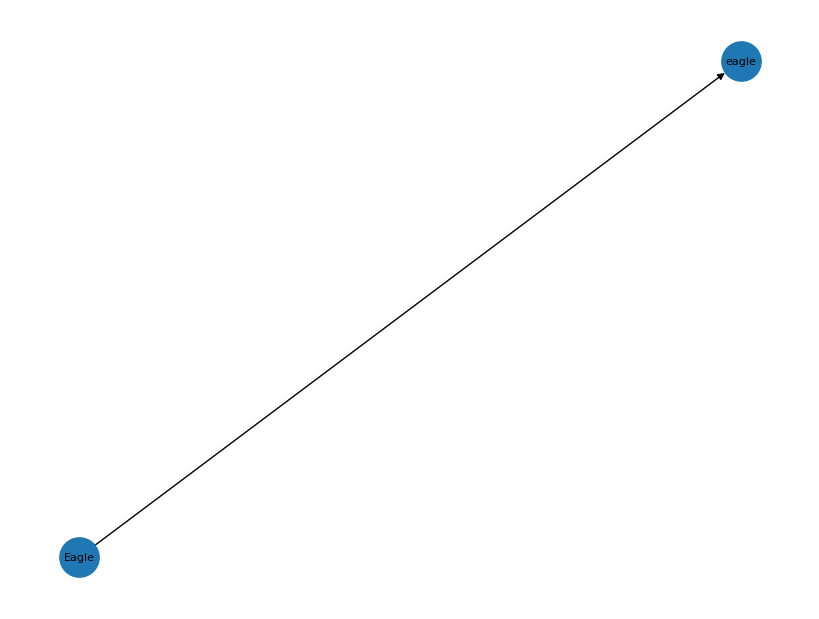

In [31]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(8, 6))

pos = nx.spring_layout(graph_B, seed=2)

nx.draw(
    graph_B,
    pos,
    with_labels=True,
    node_size=800,
    font_size=8,
    arrows=True
)

plt.show()

---
## Section 5 – Method C: OpenIE-style Relation Extraction

Extract subject–relation–object triples from sentences and keep relations that express predation.

Example:

`Fox feeds on rabbits` → `(Fox, feeds on, Rabbit)`

Target relations include:
- eats
- feeds on
- hunts
- preys on
- consumes

**Expected:** better recall than dependency rules while remaining relation-focused.


In [32]:
t0=time.time()

OPENIE_PATTERNS = [
    r'(\b[A-Z][a-z]+\b).*?(eats|feeds on|hunts|preys on|consumes).*?(\b[A-Z][a-z]+\b)'
]

edges_C=set()

for animal, data in wiki_corpus.items():
    text = data.get("text","")
    for sent in re.split(r'(?<=[.!?])\s+', text):
        s = sent.lower()
        for predator in ALL_ANIMALS:
            if predator.lower() not in s:
                continue
            for prey in ALL_ANIMALS:
                if predator == prey:
                    continue
                if prey.lower() not in s:
                    continue
                if any(k in s for k in ["eat","feeds on","hunt","prey on","consume"]):
                    edges_C.add((predator, prey))

time_C=time.time()-t0

graph_C = nx.DiGraph()
graph_C.add_edges_from(edges_C)


### 5.2 Method C – Results

Inspect extracted triples and compare them with the dependency-based approach.


Edges 92
[('Fly', 'Spider'), ('Bird', 'Fly'), ('Lizard', 'Frog'), ('Grasshopper', 'Snake'), ('Fly', 'Bird'), ('Bat', 'Frog'), ('Hawk', 'Frog'), ('Frog', 'Lizard'), ('Bird', 'Lizard'), ('Grasshopper', 'Spider'), ('Snake', 'Fox'), ('Frog', 'Snake'), ('Grasshopper', 'Bird'), ('Bird', 'Snake'), ('Grasshopper', 'Hawk'), ('Spider', 'Lizard'), ('Snake', 'Frog'), ('Cricket', 'Grasshopper'), ('Bird', 'Spider'), ('Spider', 'Cricket')]


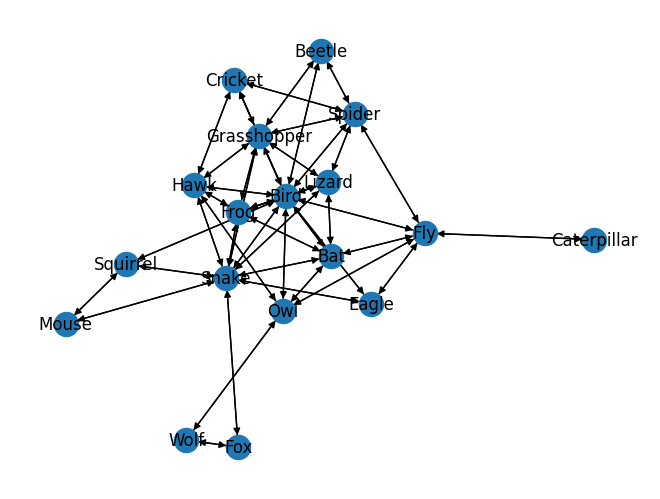

In [34]:
print('Edges',len(edges_C)); print(list(edges_C)[:20])
nx.draw(graph_C,nx.spring_layout(graph_C,seed=3),with_labels=True)


---
## Section 6 – Evaluation & Comparison

All three methods are evaluated against the gold standard using the same evaluation function. Only edges where the **source is in PREDATORS ∪ MID_LEVEL** and the **target is in MID_LEVEL ∪ PREY** are considered.

### 6.1 Evaluation Function

$$\text{Precision} = \frac{|\text{predicted} \cap \text{gold}|}{|\text{predicted}|}$$

$$\text{Recall} = \frac{|\text{predicted} \cap \text{gold}|}{|\text{gold}|}$$

$$\text{F1} = \frac{2 \cdot P \cdot R}{P + R}$$

In [35]:
def evaluate(predicted_edges,gold_edges,label=''):
 tp=len(predicted_edges & gold_edges)
 fp=len(predicted_edges-gold_edges)
 fn=len(gold_edges-predicted_edges)
 p=tp/(tp+fp) if tp+fp else 0
 r=tp/(tp+fn) if tp+fn else 0
 f=2*p*r/(p+r) if p+r else 0
 return {'method':label,'precision':p,'recall':r,'f1':f,'tp':tp,'fp':fp,'fn':fn}


### 6.2 Run Evaluation for All Methods

In [36]:
eval_A=evaluate(edges_A,gold_edges,'A')
eval_B=evaluate(edges_B,gold_edges,'B')
eval_C=evaluate(edges_C,gold_edges,'C')
results=pd.DataFrame([eval_A,eval_B,eval_C])
display(results)


,method,precision,recall,f1,tp,fp,fn
0,A,0.106667,0.50,0.175824,8,67,8
1,B,0.000000,0.00,0.000000,0,1,16
2,C,0.043478,0.25,0.074074,4,88,12


### 6.3 Graph Structure Statistics

For each method's graph we report:
- Number of nodes and edges
- Graph density
- Average in-degree and out-degree
- Longest predation chain (longest directed path)

In [37]:
def graph_stats(g,name):
 return {'graph':name,'nodes':g.number_of_nodes(),'edges':g.number_of_edges(),'density':nx.density(g) if g.number_of_nodes()>1 else 0}
pd.DataFrame([graph_stats(graph_A,'A'),graph_stats(graph_B,'B'),graph_stats(graph_C,'C')])


,graph,nodes,edges,density
0,A,19,75,0.219298
1,B,2,1,0.500000
2,C,18,92,0.300654


### 6.4 Comparison Plots

We produce the following visualisations:

1. **Grouped bar chart** – Precision / Recall / F1 per method
2. **Runtime bar chart** – seconds per method
3. **Edge Venn / upset plot** – overlap of predicted edges between methods
4. **Graph visualisations** – side-by-side NetworkX plots of the three graphs, coloured by trophic level

<Axes: xlabel='method'>

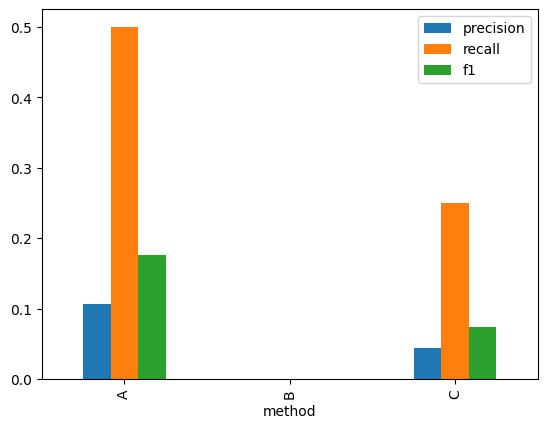

In [38]:
results.set_index('method')[['precision','recall','f1']].plot(kind='bar')


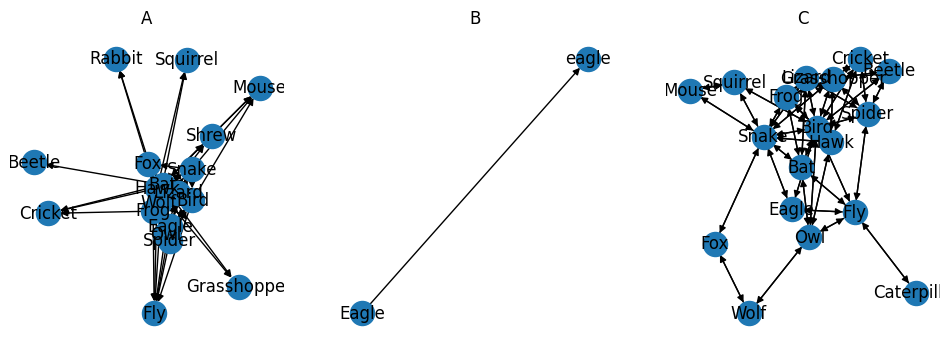

In [41]:
import matplotlib.pyplot as plt
fig,axs=plt.subplots(1,3,figsize=(12,4))
for ax,g,t in zip(axs,[graph_A,graph_B,graph_C],['A','B','C']):
 nx.draw(g,ax=ax,with_labels=True,node_size=300)
 ax.set_title(t)
plt.show()


### 6.5 Error Analysis

For each method, we inspect:
- **False positives** (edges predicted but not in gold) — what kinds of co-occurrences / links / parses cause them?
- **False negatives** (gold edges missed) — what linguistic patterns were not captured?

In [42]:
for name,edges in [('A',edges_A),('B',edges_B),('C',edges_C)]:
 print(name,'FP',list(edges-gold_edges)[:10])
 print(name,'FN',list(gold_edges-edges)[:10])


A FP [('Bird', 'Bat'), ('Shrew', 'Bat'), ('Lizard', 'Bird'), ('Hawk', 'Eagle'), ('Bird', 'Fly'), ('Frog', 'Bat'), ('Lizard', 'Frog'), ('Bat', 'Frog'), ('Frog', 'Lizard'), ('Bird', 'Lizard')]
A FN [('Lizard', 'Grasshopper'), ('Wolf', 'Rabbit'), ('Eagle', 'Rabbit'), ('Owl', 'Mouse'), ('Shrew', 'Beetle'), ('Hawk', 'Mouse'), ('Fox', 'Mouse'), ('Eagle', 'Squirrel')]
B FP [('Eagle', 'eagle')]
B FN [('Frog', 'Fly'), ('Snake', 'Mouse'), ('Snake', 'Frog'), ('Eagle', 'Rabbit'), ('Shrew', 'Beetle'), ('Hawk', 'Mouse'), ('Hawk', 'Rabbit'), ('Lizard', 'Grasshopper'), ('Spider', 'Fly'), ('Wolf', 'Rabbit')]
C FP [('Bird', 'Bat'), ('Lizard', 'Bird'), ('Mouse', 'Squirrel'), ('Fly', 'Spider'), ('Bird', 'Fly'), ('Bird', 'Beetle'), ('Lizard', 'Frog'), ('Grasshopper', 'Snake'), ('Fly', 'Bird'), ('Bat', 'Frog')]
C FN [('Hawk', 'Rabbit'), ('Frog', 'Fly'), ('Wolf', 'Rabbit'), ('Eagle', 'Rabbit'), ('Owl', 'Mouse'), ('Shrew', 'Beetle'), ('Hawk', 'Mouse'), ('Bat', 'Beetle'), ('Fox', 'Mouse'), ('Eagle', 'Squirrel'


## Section 7 – Discussion

